# CMI and Markov length for a ring of toric plaquettes — optimized version

This version avoids constructing the full dense \(2^N\times 2^N\) density matrix.

The original notebook formed objects such as `rho_0`, `Z_i @ rho @ Z_i`, and dense partial traces. Those scale as \(4^N\) in memory and crash quickly. Here we use the fact that the ground state is a uniform superposition over the bitstrings generated by the plaquette flip operators. For `P` plaquettes, only \(2^P\) computational basis states appear, while the full Hilbert space has dimension \(2^{3P}\).

The phase-flip channel is handled analytically: an off-diagonal element \(|x\rangle\langle y|\) is multiplied by

\[
\prod_{i\in E}\left[(1-p)+p(-1)^{x_i+y_i}\right]
= (1-2p)^{d_E(x,y)},
\]

where \(E\) is the set of noisy qubits and \(d_E(x,y)\) is the Hamming distance between `x` and `y` restricted to noisy qubits.


In [2]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from concurrent.futures import ProcessPoolExecutor

try:
    import scienceplots
    plt.style.use("science")
except Exception:
    # The notebook remains fully functional without scienceplots.
    pass

os.makedirs("New_plots", exist_ok=True)


In [3]:
from scipy.optimize import curve_fit

## Sparse/compact representation of the plaquette-ring ground state

A plaquette operator flips four qubits. Acting with all subsets of plaquettes on \(|0\rangle^{\otimes N}\) generates the support of the ground-state wavefunction. We store those basis states as integers rather than constructing vectors of length \(2^N\) or matrices of size \(2^N\times 2^N\).


In [4]:
def get_plaquettes(number_of_plaquettes):
    """Return plaquette qubit indices for a ring with P plaquettes and N=3P qubits."""
    P = int(number_of_plaquettes)
    N = 3 * P
    return [
        ((0 + 3*n) % N, (1 + 3*n) % N, (2 + 3*n) % N, (3 + 3*n) % N)
        for n in range(P)
    ]


def get_error_index(total_system_size):
    """Shared qubits/noisy qubits: 0, 3, 6, ..."""
    return list(range(0, int(total_system_size), 3))


def mask_from_qubits(qubits):
    """Integer bit mask with ones on the selected qubits."""
    mask = 0
    for q in qubits:
        mask |= 1 << int(q)
    return mask


def plaquette_masks(number_of_plaquettes):
    """Integer masks corresponding to the plaquette X-flip operators."""
    return [mask_from_qubits(p) for p in get_plaquettes(number_of_plaquettes)]


def generate_ground_state_support(number_of_plaquettes):
    """
    Generate the computational-basis support of the plaquette-ring ground state.
    """
    states = {0}
    for m in plaquette_masks(number_of_plaquettes):
        states |= {s ^ m for s in states}
    states = np.array(sorted(states), dtype=np.uint64)
    amplitudes = np.full(len(states), 1.0 / np.sqrt(len(states)), dtype=np.float64)
    return states, amplitudes


def restrict_bits(x, qubits):
    """
    Extract selected qubits from integer x and pack them densely.
    The first qubit in `qubits` becomes bit 0 of the returned integer.
    """
    y = 0
    xi = int(x)
    for out_pos, q in enumerate(qubits):
        y |= ((xi >> int(q)) & 1) << out_pos
    return y


print("Plaquettes for P=4:", get_plaquettes(4))
print("Noisy/error qubits for N=12:", get_error_index(12))
states_4, amps_4 = generate_ground_state_support(4)
print("Support size for P=4:", len(states_4), "instead of full Hilbert dimension", 2**12)


Plaquettes for P=4: [(0, 1, 2, 3), (3, 4, 5, 6), (6, 7, 8, 9), (9, 10, 11, 0)]
Noisy/error qubits for N=12: [0, 3, 6, 9]
Support size for P=4: 16 instead of full Hilbert dimension 4096


## Reduced density matrices without the full density matrix

For a subsystem `keep`, the reduced density matrix has entries

\[
(\rho_{\mathrm{keep}})_{x_K,y_K}
= \sum_{x_{\bar K}=y_{\bar K}} a_x a_y^* (1-2p)^{d_E(x,y)}.
\]

The code below groups basis states by their traced-out bits and accumulates only the nonzero compact block. Zero rows/columns are omitted; this does not change the entropy.


In [5]:
@dataclass
class RegionData:
    keep: tuple
    groups: list
    keep_labels: np.ndarray
    error_signatures: np.ndarray
    amplitudes: np.ndarray
    dim: int


def prepare_region_data(states, amplitudes, N, keep, error_sites):
    """Precompute grouping information for repeated reduced-density-matrix evaluations."""
    keep = tuple(sorted(set(int(q) for q in keep)))
    trace_out = tuple(q for q in range(N) if q not in keep)

    keep_keys_raw = np.array([restrict_bits(s, keep) for s in states], dtype=np.uint64)
    out_keys = np.array([restrict_bits(s, trace_out) for s in states], dtype=np.uint64)
    error_signatures = np.array([restrict_bits(s, error_sites) for s in states], dtype=np.uint64)

    # Compactify the kept basis labels. Entropies are unchanged by omitting absent basis states.
    unique_keep = {int(k): i for i, k in enumerate(sorted(set(map(int, keep_keys_raw))))}
    keep_labels = np.array([unique_keep[int(k)] for k in keep_keys_raw], dtype=np.int64)

    groups_dict = {}
    for idx, out_key in enumerate(out_keys):
        groups_dict.setdefault(int(out_key), []).append(idx)
    groups = [np.array(v, dtype=np.int64) for v in groups_dict.values()]

    return RegionData(
        keep=keep,
        groups=groups,
        keep_labels=keep_labels,
        error_signatures=error_signatures,
        amplitudes=amplitudes,
        dim=len(unique_keep),
    )


def hamming_distance_matrix_uint64(values):
    """Pairwise Hamming distances between uint64 integer signatures."""
    vals = np.asarray(values, dtype=np.uint64)
    xor = np.bitwise_xor(vals[:, None], vals[None, :])
    flat = xor.ravel()
    counts = np.fromiter((int(v).bit_count() for v in flat), dtype=np.int16, count=flat.size)
    return counts.reshape(xor.shape)


def reduced_density_matrix(region_data, p):
    """Build a compact reduced density matrix for a subsystem at noise rate p."""
    q = 1.0 - 2.0 * float(p)
    rho = np.zeros((region_data.dim, region_data.dim), dtype=np.float64)

    for inds in region_data.groups:
        labels = region_data.keep_labels[inds]
        sigs = region_data.error_signatures[inds]
        amps = region_data.amplitudes[inds]
        hdist = hamming_distance_matrix_uint64(sigs)
        block = (q ** hdist) * np.outer(amps, amps)
        np.add.at(rho, (labels[:, None], labels[None, :]), block)

    return 0.5 * (rho + rho.T)


def von_neumann_entropy_from_rho(rho, tol=1e-12):
    """Von Neumann entropy in bits."""
    eigvals = np.linalg.eigvalsh(rho)
    eigvals = eigvals[eigvals > tol]
    return float(-np.sum(eigvals * np.log2(eigvals)))


## CMI calculator

The class below caches the compact ground-state support and precomputes region data. It can be reused for many noise rates.


In [6]:
class PlaquetteRingCMI:
    """Optimized CMI calculator for the plaquette ring."""

    def __init__(self, number_of_plaquettes, A, B, C, error_sites=None):
        self.P = int(number_of_plaquettes)
        self.N = 3 * self.P
        self.A = tuple(A)
        self.B = tuple(B)
        self.C = tuple(C)
        self.error_sites = tuple(get_error_index(self.N) if error_sites is None else error_sites)
        self.states, self.amplitudes = generate_ground_state_support(self.P)

        AB = sorted(set(self.A + self.B))
        BC = sorted(set(self.B + self.C))
        ABC = sorted(set(self.A + self.B + self.C))
        B_only = sorted(set(self.B))

        self.region_data = {
            "AB": prepare_region_data(self.states, self.amplitudes, self.N, AB, self.error_sites),
            "BC": prepare_region_data(self.states, self.amplitudes, self.N, BC, self.error_sites),
            "ABC": prepare_region_data(self.states, self.amplitudes, self.N, ABC, self.error_sites),
            "B": prepare_region_data(self.states, self.amplitudes, self.N, B_only, self.error_sites),
        }

    def entropy(self, region_name, p):
        rho = reduced_density_matrix(self.region_data[region_name], p)
        return von_neumann_entropy_from_rho(rho)

    def cmi(self, p):
        S_AB = self.entropy("AB", p)
        S_BC = self.entropy("BC", p)
        S_ABC = self.entropy("ABC", p)
        S_B = self.entropy("B", p)
        return S_AB + S_BC - S_ABC - S_B


## Example: 4 plaquettes / 12 qubits

This reproduces the first calculation, but no full \(4096\times4096\) density matrix is formed.


In [7]:
# Regions for 12 qubits / 4 plaquettes
A = [1, 2]
B = [3, 4, 5, 6, 9, 10, 11, 0]
C = [7, 8]

calculator_4 = PlaquetteRingCMI(number_of_plaquettes=4, A=A, B=B, C=C)
print("N:", calculator_4.N)
print("Ground-state support size:", len(calculator_4.states))
print("Compact dimensions:", {name: data.dim for name, data in calculator_4.region_data.items()})

p_array = np.linspace(0.001, 0.999, 40)
cmi_array = np.array([calculator_4.cmi(p) for p in p_array])

print("CMI range:", cmi_array.min(), cmi_array.max())


N: 12
Ground-state support size: 16
Compact dimensions: {'AB': 16, 'BC': 16, 'ABC': 16, 'B': 16}
CMI range: 0.0040326693076710995 0.9999987643366346


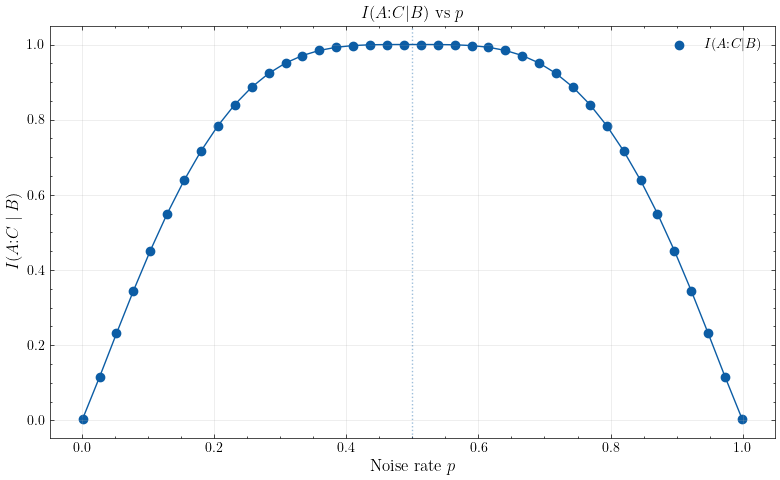

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p_array, cmi_array, lw=1)
ax.scatter(p_array, cmi_array, label=r"$I(A{:}C|B)$")
ax.axvline(0.5, ls=":", alpha=0.4)
ax.set_xlabel(r"Noise rate $p$", fontsize=12)
ax.set_ylabel(r"$I(A{:}C \mid B)$", fontsize=12)
ax.set_title(r"$I(A{:}C|B)$ vs $p$", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("New_plots/CMI_vs_p_plaquette_ring_optimized.png", dpi=300)
plt.show()


## Optional validation against the original dense method

This cell is disabled by default because the dense version is exactly what becomes expensive. For small systems it can be useful to check that both methods agree.


In [9]:
RUN_DENSE_VALIDATION = False

if RUN_DENSE_VALIDATION:
    from functools import reduce

    ket_0 = np.array([1, 0], dtype=float)
    Pauli_X = np.array([[0, 1], [1, 0]], dtype=float)
    Pauli_Z = np.array([[1, 0], [0, -1]], dtype=float)
    I2 = np.eye(2)

    def local_operator(op, i, N):
        ops = [I2] * N
        ops[i] = op
        return reduce(np.kron, ops)

    def plaquette_operator(i1, i2, i3, i4, N):
        return (
            local_operator(Pauli_X, i1, N)
            @ local_operator(Pauli_X, i2, N)
            @ local_operator(Pauli_X, i3, N)
            @ local_operator(Pauli_X, i4, N)
        )

    def ground_state_dense(N, plaquettes):
        ket_0N = reduce(np.kron, [ket_0] * N)
        P_op = np.eye(2**N)
        for plaq in plaquettes:
            Aop = plaquette_operator(*plaq, N)
            P_op = ((np.eye(2**N) + Aop) / np.sqrt(2)) @ P_op
        ket = P_op @ ket_0N
        ket = ket / np.linalg.norm(ket)
        return ket

    def phase_flip_channel_dense(rho, p, i, N):
        Zi = local_operator(Pauli_Z, i, N)
        return (1 - p) * rho + p * (Zi @ rho @ Zi)

    def noise_channel_dense(rho0, p, N, indexlist):
        rho = rho0
        for i in indexlist:
            rho = phase_flip_channel_dense(rho, p, i, N)
        return rho

    def partial_trace_dense(rho, keep, N):
        keep = sorted(keep)
        trace_out = [q for q in range(N) if q not in keep]
        rho_tensor = rho.reshape([2] * N + [2] * N)
        current_N = N
        for q in sorted(trace_out, reverse=True):
            rho_tensor = np.trace(rho_tensor, axis1=q, axis2=q + current_N)
            current_N -= 1
        return rho_tensor.reshape(2 ** len(keep), 2 ** len(keep))

    def entropy_dense(rho):
        vals = np.linalg.eigvalsh(rho)
        vals = vals[vals > 1e-12]
        return -np.sum(vals * np.log2(vals))

    def cmi_dense(p, N, A, B, C):
        ket = ground_state_dense(N, get_plaquettes(N // 3))
        rho0 = np.outer(ket, ket.conj())
        rho = noise_channel_dense(rho0, p, N, get_error_index(N))
        AB = sorted(set(A + B))
        BC = sorted(set(B + C))
        ABC = sorted(set(A + B + C))
        return (
            entropy_dense(partial_trace_dense(rho, AB, N))
            + entropy_dense(partial_trace_dense(rho, BC, N))
            - entropy_dense(partial_trace_dense(rho, ABC, N))
            - entropy_dense(partial_trace_dense(rho, B, N))
        )

    p_test = 0.23
    dense_value = cmi_dense(p_test, 12, A, B, C)
    compact_value = calculator_4.cmi(p_test)
    print("dense:", dense_value)
    print("compact:", compact_value)
    print("absolute difference:", abs(dense_value - compact_value))


## Markov length calculation

The partitioning below follows the original notebook. For distance `d`, the system size is `N = 6d + 6`, so the number of plaquettes is `P = 2d + 2`.


In [10]:
def partition_for_distance(d):
    """Return A, B, C and system size for the distance-dependent partition."""
    d = int(d)
    A_d = list(range(1, 3))
    B_d = list(range(0, 1)) + list(range(3, 3 + d*3 + 1)) + list(range(3 + d*3 + 3, 3 + d*3 + 3 + d*3))
    C_d = list(range(3 + d*3 + 1, 3 + d*3 + 3))
    system_size = len(A_d + B_d + C_d)
    number_of_plaquettes = system_size // 3
    return A_d, B_d, C_d, system_size, number_of_plaquettes


def cmi_for_distance_and_p(args):
    """Top-level worker function so it can be used with ProcessPoolExecutor."""
    d, p = args
    A_d, B_d, C_d, system_size, P = partition_for_distance(d)
    calc = PlaquetteRingCMI(P, A=A_d, B=B_d, C=C_d)
    return calc.cmi(p)


def compute_cmi_matrix(p_values, distances, parallel=False, max_workers=None):
    """
    Compute CMI[p_index, distance_index].

    Parallelization is over independent (p, distance) pairs. Algorithmic compression is
    the main speed/memory improvement; parallelization is optional.
    """
    p_values = np.asarray(p_values, dtype=float)
    distances = np.asarray(distances, dtype=int)
    tasks = [(int(d), float(p)) for p in p_values for d in distances]

    if parallel:
        with ProcessPoolExecutor(max_workers=max_workers) as pool:
            values = list(pool.map(cmi_for_distance_and_p, tasks))
    else:
        values = [cmi_for_distance_and_p(t) for t in tasks]

    return np.array(values, dtype=float).reshape(len(p_values), len(distances))


def fit_markov_length_offset(distances, cmi_values, offset=0.0, threshold=1e-12):
    """Fit CMI(r) - offset = a exp(-r/xi)."""
    distances = np.array(distances, dtype=float)
    cmi_values = np.array(cmi_values, dtype=float)
    shifted = cmi_values - offset
    mask = shifted > threshold

    if np.sum(mask) < 2:
        return np.nan

    x = distances[mask]
    y = np.log(shifted[mask])
    slope, intercept = np.polyfit(x, y, 1)

    if slope >= 0:
        return np.nan
    return -1.0 / slope


In [11]:
# Noise rates and distances used to evaluate Markov length.
p_array2 = np.linspace(0.001, 0.999, 40)

# Increase this after testing. The optimized code should handle larger R_max than the dense notebook.
R_max = 5
distances = np.arange(1, R_max + 1)

# Set parallel=True for larger sweeps. For small sweeps, serial is often faster due to process overhead.
cmi_matrix = compute_cmi_matrix(p_array2, distances, parallel=False)

xi_array = np.array([
    fit_markov_length_offset(distances, cmi_matrix[ip], offset=0.0)
    for ip in range(len(p_array2))
])

print("CMI matrix shape:", cmi_matrix.shape)
print("xi_array:")
print(xi_array)
print("finite xi values:", np.sum(np.isfinite(xi_array)))


CMI matrix shape: (40, 5)
xi_array:
[3.47032159e-01 8.18912199e-01 1.13845048e+00 1.48014007e+00
 1.87886836e+00 2.36650338e+00 2.98412166e+00 3.79163128e+00
 4.88236227e+00 6.40965320e+00 8.63961511e+00 1.20640524e+01
 1.76637682e+01 2.75906036e+01 4.71877566e+01 9.21436667e+01
 2.21071000e+02 7.54485109e+02 5.29998246e+03 4.06974318e+05
 4.06974318e+05 5.29998246e+03 7.54485109e+02 2.21071000e+02
 9.21436667e+01 4.71877566e+01 2.75906036e+01 1.76637682e+01
 1.20640524e+01 8.63961511e+00 6.40965320e+00 4.88236227e+00
 3.79163128e+00 2.98412166e+00 2.36650338e+00 1.87886836e+00
 1.48014007e+00 1.13845048e+00 8.18912199e-01 3.47032159e-01]
finite xi values: 40


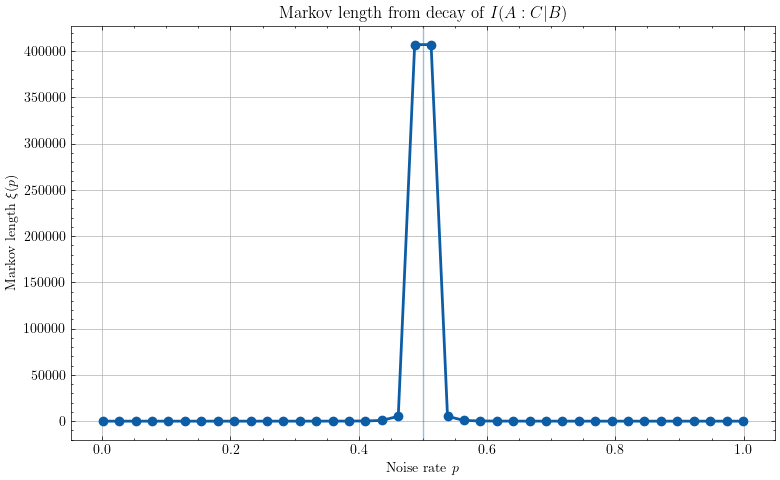

In [12]:
valid = np.isfinite(xi_array)

plt.figure(figsize=(8, 5))
plt.plot(p_array2[valid], xi_array[valid], marker="o", lw=2)
plt.axvline(0.5, ls="-", alpha=0.4)
plt.xlabel(r"Noise rate $p$")
plt.ylabel(r"Markov length $\xi(p)$")
plt.title(r"Markov length from decay of $I(A:C|B)$")
plt.tight_layout()
plt.grid(True)
plt.savefig("New_plots/Xi_vs_p_plaquette_ring_optimized.png", dpi=300)
plt.show()


Best-fit model:
y = (x - a)^(-b)

Parameters with 1-sigma uncertainties:
a = 0.5 ± 1.9e-05
b = 2.9631991 ± 0.00099

Goodness of fit:
R^2 = 0.99925726
Reduced chi-square = 6141583.7

Covariance matrix:
[[ 3.46153570e-10 -4.24861417e-14]
 [-4.24861417e-14  9.76562967e-07]]

Correlation matrix:
[[ 1.00000000e+00 -2.31080213e-06]
 [-2.31080213e-06  1.00000000e+00]]


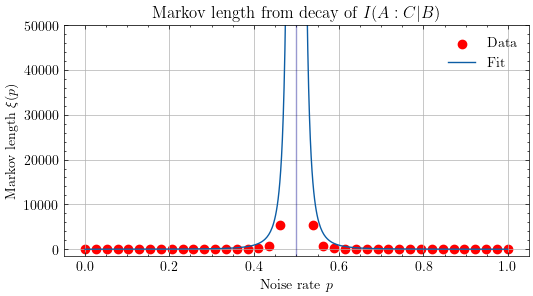

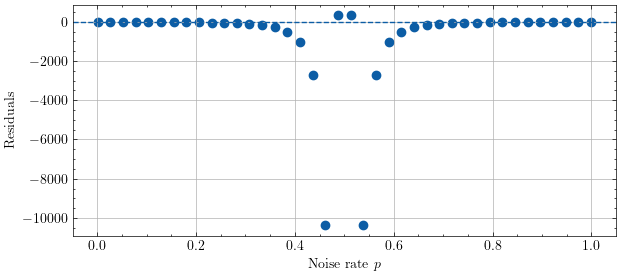

In [22]:
# Replace with your data
xdata = p_array2
ydata = xi_array

# Optional: replace with your y-errors if known
# sigma = np.array([...])
sigma = None

# Model: y = c (x - a)^(-b), with b > 1 and a < min(x)
def model(x, a, b):
    return abs(x-a)**(-b)

# Initial guesses
p0 = [0.5, 2.0]  # a, b

# Bounds: a < min(xdata), b > 1
bounds = (
    [0.001, 1.000001],
    [0.999, 20.0]
)

# Fit
if sigma is None:
    popt, pcov = curve_fit(
        model, xdata, ydata,
        p0=p0,
        bounds=bounds,
        maxfev=10000
    )
else:
    popt, pcov = curve_fit(
        model, xdata, ydata,
        p0=p0,
        bounds=bounds,
        sigma=sigma,
        absolute_sigma=True,
        maxfev=10000
    )

# Best-fit parameters
a_fit, b_fit = popt

# 1-sigma parameter uncertainties
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr

# Fitted values and residuals
yfit = model(xdata, *popt)
residuals = ydata - yfit

# R^2
ss_res = np.sum(residuals**2)
ss_tot = np.sum((ydata - np.mean(ydata))**2)
r_squared = 1 - ss_res / ss_tot

# Reduced chi-square
n = len(ydata)
p = len(popt)

if sigma is not None:
    chi2 = np.sum((residuals / sigma)**2)
else:
    # Uses unweighted residuals; mainly useful for comparison, not formal statistics
    chi2 = np.sum(residuals**2)

chi2_red = chi2 / (n - p)

# Correlation matrix
corr = pcov / np.outer(perr, perr)

# Print results
print("Best-fit model:")
print(f"y = (x - a)^(-b)")
print()

print("Parameters with 1-sigma uncertainties:")
print(f"a = {a_fit:.8g} ± {a_err:.2g}")
print(f"b = {b_fit:.8g} ± {b_err:.2g}")
print()

print("Goodness of fit:")
print(f"R^2 = {r_squared:.8g}")
print(f"Reduced chi-square = {chi2_red:.8g}")
print()

print("Covariance matrix:")
print(pcov)
print()

print("Correlation matrix:")
print(corr)

# Plot fit
xplot = np.linspace(min(xdata), max(xdata), 500)
yplot = model(xplot, *popt)

plt.figure(figsize=(6, 3))

if sigma is None:
    plt.scatter(xdata, ydata, label="Data", color = "red")
else:
    plt.errorbar(xdata, ydata, yerr=sigma, fmt="o", capsize=3, label="Data")

plt.plot(xplot, yplot, label="Fit")
plt.xlabel(r"Noise rate $p$")
plt.ylabel(r"Markov length $\xi (p)$")
plt.title(r"Markov length from decay of $I(A:C|B)$")
plt.axvline(0.5, color='darkblue', ls='-', alpha=0.4)
plt.legend()
plt.ylim(-1500,50000)
plt.grid(True)
plt.savefig("New_plots/Xi_vs_p_fitted_plaquette.png", dpi=300)
plt.show()

# Plot residuals
plt.figure(figsize=(7, 3))
plt.axhline(0, linestyle="--")
plt.scatter(xdata, residuals)
plt.xlabel(r"Noise rate $p$")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()

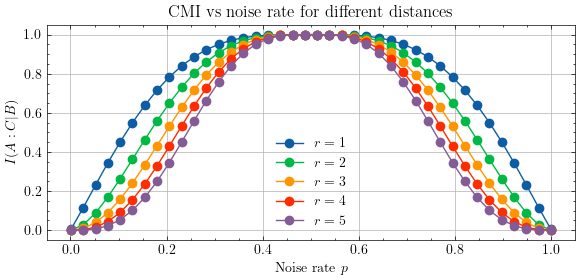

In [23]:
plt.figure(figsize=(6, 3))

for idx, r in enumerate(distances):
    plt.plot(p_array2, cmi_matrix[:, idx], marker="o", label=fr"$r={r}$")

plt.xlabel(r"Noise rate $p$")
plt.ylabel(r"$I(A:C|B)$")
plt.title(r"CMI vs noise rate for different distances")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("New_plots/CMI_vs_p_different_r_plaquette_ring_optimized.png", dpi=300)
plt.show()


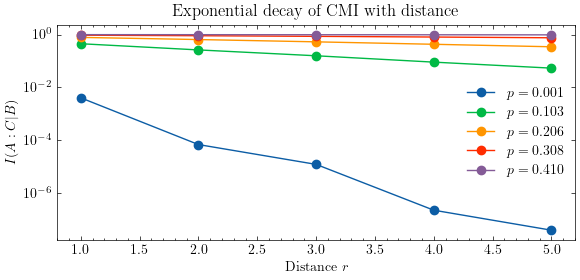

In [24]:
plt.figure(figsize=(6, 3))

for idx in range(0, 20, 4):
    vals = cmi_matrix[idx]
    mask = vals > 1e-12
    if np.any(mask):
        plt.plot(distances[mask], vals[mask], marker="o", label=fr"$p={p_array2[idx]:.3f}$")

plt.yscale("log")
plt.xlabel(r"Distance $r$")
plt.ylabel(r"$I(A:C|B)$")
plt.title(r"Exponential decay of CMI with distance")
plt.legend(loc="center right")
plt.tight_layout()
plt.savefig("New_plots/CMI_decay_with_r_plaquette_ring_optimized.png", dpi=300)
plt.show()
